# PINN Inverse Heston


In [1]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim


### Colab Setup


In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")


Cloning into '/content/fys5429'...
remote: Enumerating objects: 951, done.
remote: Counting objects: 100% (297/297), done.
remote: Compressing objects: 100% (202/202), done.
remote: Total 951 (delta 197), reused 192 (delta 94), pack-reused 654 (from 1)
Receiving objects: 100% (951/951), 65.15 MiB | 73.39 MiB/s, done.
Resolving deltas: 100% (499/499), done.
Working directory: /content/fys5429/code/notebooks


### Paths


In [3]:
data_path = Path("..") / "data" / "generated" / "inv_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/final")
else:
    out_dir = Path("..") / "plots" / "final"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")

out_path_pinn = out_dir / "pinn_inv.pdf"
out_path_loss_total = out_dir / "pinn_inv_loss_total.pdf"
out_path_loss_pde = out_dir / "pinn_inv_loss_pde.pdf"
out_path_loss_ic = out_dir / "pinn_inv_loss_ic.pdf"
out_path_loss_bc = out_dir / "pinn_inv_loss_bc.pdf"
out_path_loss_data = out_dir / "pinn_inv_loss_data.pdf"
out_path_params = out_dir / "pinn_inv_params.pdf"


Mounted at /content/drive
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/final


### Global parameters


In [4]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.backends.cudnn.benchmark = True

# Domain
S_max = 300.0
T_max = 1.0
K = 100.0
r = 0.05
v_min = 0.01
v_max = 1.0
v0 = 0.04

# True Heston parameters (targets for calibration)
TRUE_KAPPA = 2.0
TRUE_THETA = 0.04
TRUE_XI = 0.3
TRUE_RHO = -0.7

# NN architecture (proven from forward sweeps)
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 256
LEARNING_RATE = 5e-3
LR_HESTON = 1e-3            # NEW: slower LR for Heston params
EPOCHS = 50000
PRINT_ROWS = 20

# Loss weights (updated from hyper_inv_1_data.ipynb sweep)
LAMBDA_PDE = 10.0
LAMBDA_IC = 10.0
LAMBDA_BC = 5.0
LAMBDA_DATA = 50.0          # BEST FROM SWEEP
LAMBDA_FELLER = 1.0         # NEW: Feller condition penalty weight

# Intentionally wrong initial guesses
KAPPA_INIT = 1.0
THETA_INIT = 0.1
XI_INIT = 0.5
RHO_INIT = 0.0


Using device: cuda


In [5]:
import sys
sys.path.insert(0, "../scripts")
from invpinn import INVPINN

### Reading data


In [6]:
df_all = pd.read_parquet(data_path)

def extract_tensors(df_subset):
    S = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    v = torch.tensor(df_subset['v'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S, v, tau

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, v_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, v_ic, tau_ic = extract_tensors(df_ic)

df_bc = df_all[df_all['point_type'] == 'boundary_S_lower']
S_bc, v_bc, tau_bc = extract_tensors(df_bc)

df_data = df_all[df_all['point_type'] == 'market_data']
S_data, v_data, tau_data = extract_tensors(df_data)
V_data = torch.tensor(df_data['V_data'].values, dtype=torch.float32).view(-1, 1).to(device)

print(f"Read data from {data_path}")
print(f"Interior: {len(S_in)}, IC: {len(S_ic)}, BC: {len(S_bc)}, Data: {len(S_data)}")

Read data from ../data/generated/inv_collocation.parquet
Interior: 10000, IC: 2000, BC: 250, Data: 200


In [7]:
model = INVPINN(hidden_layers=HIDDEN_LAYERS, neurons_per_layer=NEURONS_PER_LAYER,
                activation='tanh',
                kappa_init=KAPPA_INIT, theta_init=THETA_INIT,
                xi_init=XI_INIT, rho_init=RHO_INIT).to(device)
optimizer = optim.Adam(model.param_groups(lr_nn=LEARNING_RATE, lr_heston=LR_HESTON))
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

### Training Loop


In [ ]:
epochs = EPOCHS
print(f"Starting Inverse PINN calibration at {epochs} epochs")
print(f"Initial guesses: κ={KAPPA_INIT}, θ={THETA_INIT}, ξ={XI_INIT}, ρ={RHO_INIT}")
print(f"True values:     κ={TRUE_KAPPA}, θ={TRUE_THETA}, ξ={TRUE_XI}, ρ={TRUE_RHO}")

Starting Inverse PINN calibration at 50000 epochs
Initial guesses: κ=1.0, θ=0.1, ξ=0.5, ρ=0.0
True values:     κ=2.0, θ=0.04, ξ=0.3, ρ=-0.7


In [9]:
history = {
    'epoch': [], 'total': [], 'pde': [], 'ic': [], 'bc': [], 'data': [], 'feller': [],
    'kappa': [], 'theta': [], 'xi': [], 'rho': []
}

print(f"{'Epoch':>6} | {'Total':>12} | {'PDE':>10} | {'IC':>10} | {'BC':>10} | {'Data':>10} | {'Feller':>10} | {'κ':>6} {'θ':>7} {'ξ':>6} {'ρ':>7}")
print("-" * 120)

grad_ones = torch.ones_like(S_in)
start_time = time.time()

for epoch in range(epochs):
    optimizer.zero_grad()

    kappa = model.kappa
    theta = model.theta
    xi    = model.xi
    rho   = model.rho

    # PDE residual
    V_pred = model(S_in, v_in, tau_in)
    V_S   = torch.autograd.grad(V_pred, S_in,   grad_outputs=grad_ones, create_graph=True)[0]
    V_v   = torch.autograd.grad(V_pred, v_in,   grad_outputs=grad_ones, create_graph=True)[0]
    V_tau = torch.autograd.grad(V_pred, tau_in,  grad_outputs=grad_ones, create_graph=True)[0]
    V_SS  = torch.autograd.grad(V_S, S_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_vv  = torch.autograd.grad(V_v, v_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_Sv  = torch.autograd.grad(V_S, v_in, grad_outputs=grad_ones, create_graph=True)[0]

    pde_residual = V_tau - (
        0.5 * v_in * S_in**2 * V_SS
        + rho * xi * v_in * S_in * V_Sv
        + 0.5 * xi**2 * v_in * V_vv
        + r * S_in * V_S
        + kappa * (theta - v_in) * V_v
        - r * V_pred
    )
    loss_pde = torch.mean(pde_residual**2)

    # IC loss
    V_ic_pred = model(S_ic, v_ic, tau_ic)
    V_ic_true = torch.relu(S_ic - K)
    loss_ic = torch.mean((V_ic_pred - V_ic_true)**2)

    # BC loss
    V_bc_pred = model(S_bc, v_bc, tau_bc)
    loss_bc = torch.mean((V_bc_pred - 0.0)**2)

    # Data loss
    V_data_pred = model(S_data, v_data, tau_data)
    loss_data = torch.mean((V_data_pred - V_data)**2)

    # Feller condition penalty: 2*kappa*theta > xi^2
    feller_violation = torch.relu(xi**2 - 2.0 * kappa * theta)
    loss_feller = feller_violation**2

    # Total
    loss = (LAMBDA_PDE * loss_pde + LAMBDA_IC * loss_ic
            + LAMBDA_BC * loss_bc + LAMBDA_DATA * loss_data
            + LAMBDA_FELLER * loss_feller)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    # Record history
    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['bc'].append(loss_bc.item())
    history['data'].append(loss_data.item())
    history['feller'].append(loss_feller.item())
    history['kappa'].append(kappa.item())
    history['theta'].append(theta.item())
    history['xi'].append(xi.item())
    history['rho'].append(rho.item())

    # Print progress
    print_interval = max(1, epochs // PRINT_ROWS)
    if epoch % print_interval == 0:
        print(f"{epoch:6d} | {loss.item():12.4f} | {loss_pde.item():10.6f} | {loss_ic.item():10.4f} | {loss_bc.item():10.6f} | {loss_data.item():10.4f} | {loss_feller.item():10.6f} | "
              f"{kappa.item():6.3f} {theta.item():7.4f} {xi.item():6.3f} {rho.item():7.3f}")

end_time = time.time()
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

print("-" * 120)
print(f"Calibration Complete! {epochs} epochs in {minutes}m {seconds}s")
print(f"Final params: κ={kappa.item():.4f}  θ={theta.item():.6f}  ξ={xi.item():.4f}  ρ={rho.item():.4f}")
print(f"True  params: κ={TRUE_KAPPA}  θ={TRUE_THETA}  ξ={TRUE_XI}  ρ={TRUE_RHO}")
print("=" * 120)

 Epoch |        Total |        PDE |         IC |         BC |       Data |     Feller |      κ       θ      ξ       ρ
------------------------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     0 |  344980.7188 |   0.010807 |  4686.0298 |   0.010441 |  5962.4048 |   0.002500 |  1.000  0.1000  0.500   0.000
  2500 |    3095.7524 | 119.053375 |    63.1620 |   0.073594 |    25.4646 |   0.000000 |  0.888  0.0749  0.264  -0.639
  5000 |     862.3738 |  60.436413 |     9.2524 |   0.265347 |     3.2832 |   0.000000 |  0.907  0.0555  0.234  -0.811
  7500 |     998.4677 |  84.807770 |     6.5282 |   0.197716 |     1.6824 |   0.000000 |  0.819  0.0505  0.236  -0.910
 10000 |     716.8978 |  14.559999 |    12.4085 |   0.183202 |     8.9259 |   0.000000 |  0.744  0.0469  0.246  -0.960
 12500 |     736.4612 |  29.435568 |     7.2482 |   0.038588 |     7.3886 |   0.000123 |  0.680  0.0426  0.263  -0.983
 15000 |    2278.7603 |  61.728111 |    35.0281 |   0.452435 |    26.1787 |   0.000883 |  0.646  0.0372  0.279  -0.992
 17500 |     473.7363 |  33.242569 |     7.4025 |   0.036055 |     1.3421 |   0.001739 |  0.622  0.0325  0.286  -0.996
 20000 |     339.0258 |  17.796406 |     3.5495 

### Parameter Convergence Plot


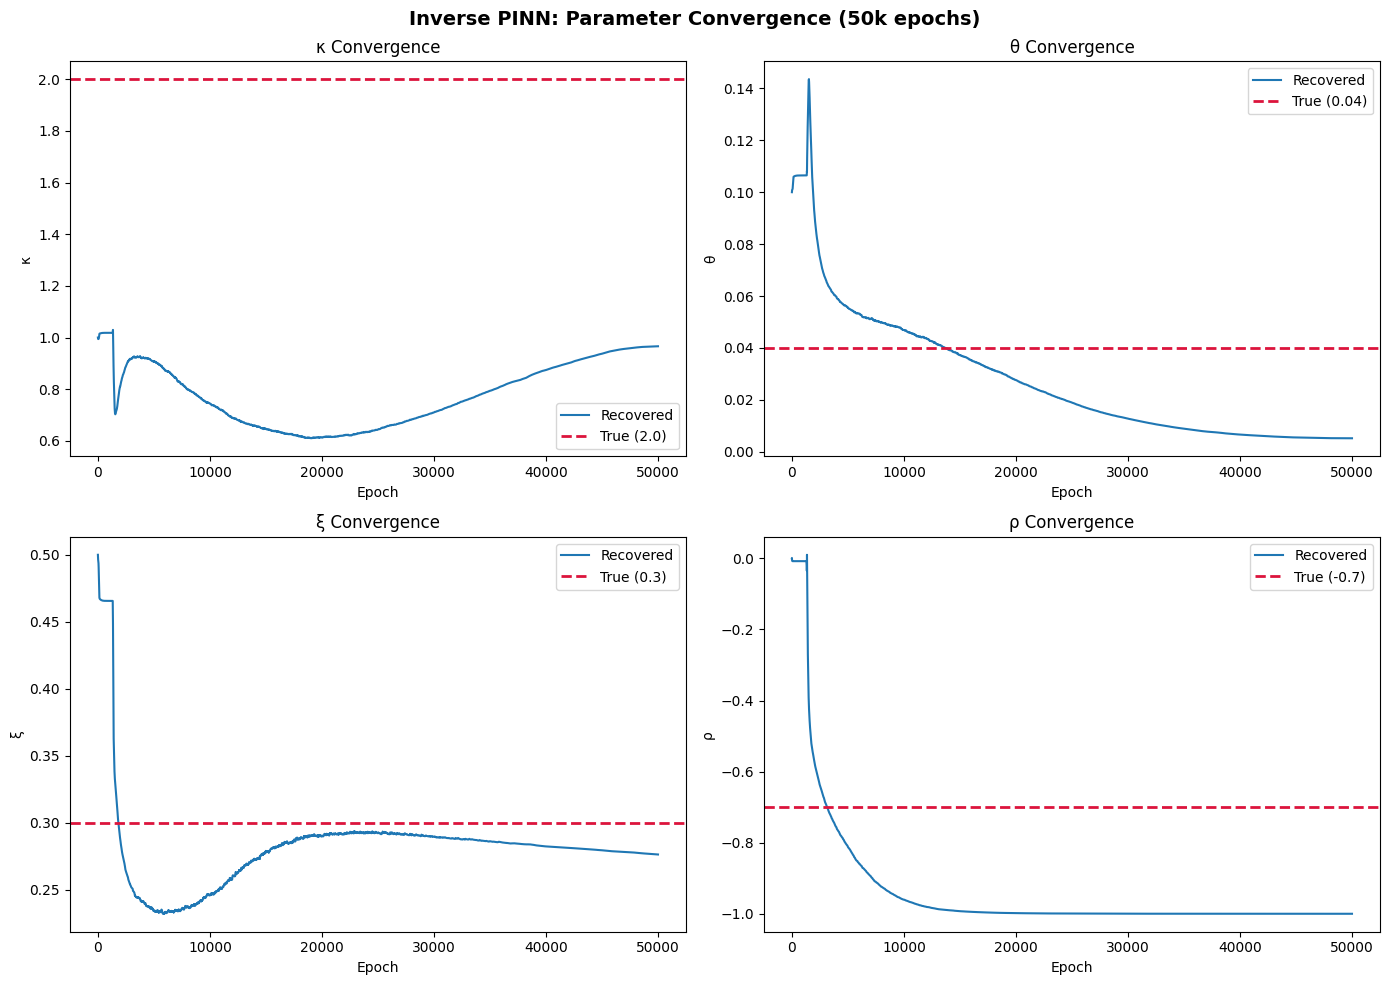

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

params = [('kappa', 'κ', TRUE_KAPPA), ('theta', 'θ', TRUE_THETA),
          ('xi', 'ξ', TRUE_XI), ('rho', 'ρ', TRUE_RHO)]

for ax, (key, label, true_val) in zip(axes.flat, params):
    ax.plot(history['epoch'], history[key], label='Recovered', linewidth=1.5)
    ax.axhline(y=true_val, color='crimson', linestyle='--', linewidth=2, label=f'True ({true_val})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.set_title(f'{label} Convergence')
    ax.legend()

plt.suptitle('Inverse PINN: Parameter Convergence (50k epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_path_params, bbox_inches="tight")
plt.show()

### Loss Curves


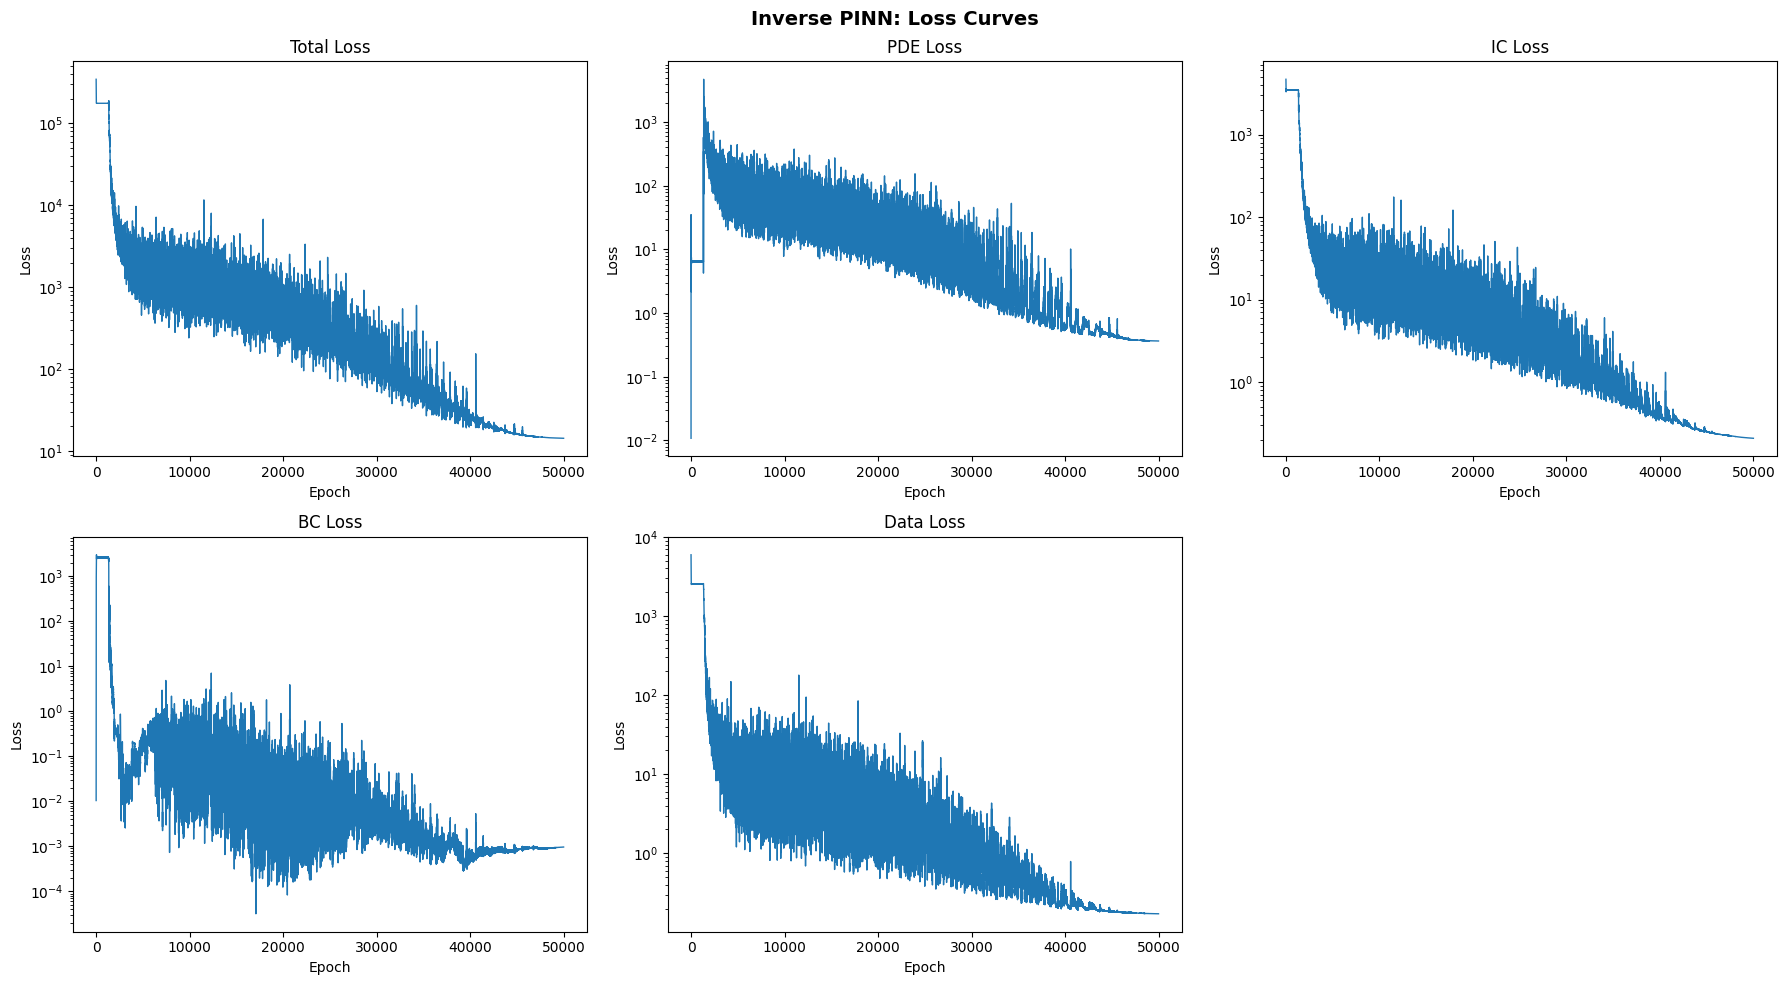

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

loss_keys = [('total', 'Total Loss'), ('pde', 'PDE Loss'), ('ic', 'IC Loss'),
             ('bc', 'BC Loss'), ('data', 'Data Loss')]
out_paths = [out_path_loss_total, out_path_loss_pde, out_path_loss_ic,
             out_path_loss_bc, out_path_loss_data]

for i, (ax, (key, title)) in enumerate(zip(axes.flat, loss_keys)):
    ax.semilogy(history['epoch'], history[key], linewidth=1)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)

# Hide the unused 6th subplot
axes.flat[5].set_visible(False)

plt.suptitle('Inverse PINN: Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / "pinn_inv_losses.pdf", bbox_inches="tight")
plt.show()


In [12]:
if IN_COLAB:
    from google.colab import drive
    drive.flush_and_unmount()
    print("Google Drive flushed and unmounted safely.")


Google Drive flushed and unmounted safely.
